[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [1]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Heart Disease dataset** directamente desde el repositorio UCI Machine Learning a través de una URL pública.

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = masculino, 0 = femenino) |
| `cp` | Tipo de dolor torácico (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `restecg` | Resultados electrocardiográficos en reposo |
| `thalach` | Frecuencia cardíaca máxima alcanzada |
| `exang` | Angina inducida por ejercicio (1 = sí) |
| `oldpeak` | Depresión del ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST |
| `ca` | Número de vasos coloreados por fluoroscopía |
| `thal` | Thalassemia (0-3) |
| `target` | Diagnóstico de enfermedad cardíaca (1 = presente, 0 = ausente) |

In [2]:
URL = 'https://raw.githubusercontent.com/reddyprasade/Machine-Learning/master/Heart-Disease-UCI/heart.csv'

# Intentamos cargar desde la URL; si falla, usamos la copia local de Kaggle
try:
    df = pd.read_csv(URL)
    print(f'Dataset cargado desde URL — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde URL: {e}')
    print('Intentando cargar desde OpenML como alternativa...')
    # Alternativa: descarga desde el repo de Kaggle vía sklearn
    from sklearn.datasets import fetch_openml
    import scipy.sparse
    try:
        # First, fetch the full bunch to get feature names (return_X_y=False)
        full_bunch = fetch_openml(data_id=1574, as_frame=False, return_X_y=False)
        feature_names = full_bunch.feature_names

        # Then, explicitly fetch X (features) and y (target) as arrays (return_X_y=True)
        X_openml, y_openml = fetch_openml(data_id=1574, as_frame=False, return_X_y=True)

        # Check if X is a sparse matrix and convert to dense if necessary
        if scipy.sparse.issparse(X_openml):
            X_openml = X_openml.toarray()

        # Create a DataFrame from the data and target arrays
        df = pd.DataFrame(data=X_openml, columns=feature_names)
        df['target'] = y_openml

        # Ensure target is numeric, as OpenML often returns it as object type
        df['target'] = pd.to_numeric(df['target'])

        print(f'Dataset cargado desde OpenML — {df.shape[0]} registros, {df.shape[1]} columnas')
    except Exception as openml_e:
        print(f'Error al cargar desde OpenML: {openml_e}')
        print('No se pudo cargar el dataset desde ninguna fuente.')
        raise # Re-raise the exception if both methods fail

df.head()

Error al cargar desde URL: HTTP Error 404: Not Found
Intentando cargar desde OpenML como alternativa...
Dataset cargado desde OpenML — 270 registros, 14 columnas


,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
0,0.708333,1.0,1.000000,-0.320755,-0.105023,-1.0,1.0,-0.419847,-1.0,-0.225806,0.0,1.000000,-1.0,1.0
1,0.583333,-1.0,0.333333,-0.603774,1.000000,-1.0,1.0,0.358779,-1.0,-0.483871,0.0,-1.000000,1.0,-1.0
2,0.166667,1.0,-0.333333,-0.433962,-0.383562,-1.0,-1.0,0.068702,-1.0,-0.903226,-1.0,-1.000000,1.0,1.0
3,0.458333,1.0,1.000000,-0.358491,-0.374429,-1.0,-1.0,-0.480916,1.0,-0.935484,0.0,-0.333333,1.0,-1.0
4,0.875000,-1.0,-0.333333,-0.509434,-0.347032,-1.0,1.0,-0.236641,1.0,-0.935484,-1.0,-0.333333,-1.0,-1.0


---
## 3. Etapa 2 — Exploración y preparación de datos

In [3]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   att_1   270 non-null    float64
 1   att_2   270 non-null    float64
 2   att_3   270 non-null    float64
 3   att_4   270 non-null    float64
 4   att_5   270 non-null    float64
 5   att_6   270 non-null    float64
 6   att_7   270 non-null    float64
 7   att_8   270 non-null    float64
 8   att_9   270 non-null    float64
 9   att_10  270 non-null    float64
 10  att_11  270 non-null    float64
 11  att_12  270 non-null    float64
 12  att_13  270 non-null    float64
 13  target  270 non-null    float64
dtypes: float64(14)
memory usage: 29.7 KB




,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,0.06,0.36,0.45,-0.30,-0.44,-0.70,0.02,0.20,-0.34,-0.66,-0.41,-0.55,-0.15,-0.11
std,0.38,0.94,0.63,0.34,0.24,0.71,1.00,0.35,0.94,0.37,0.61,0.63,0.97,1.00
min,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,-0.21,-1.00,0.33,-0.51,-0.60,-1.00,-1.00,-0.05,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
50%,0.08,1.00,0.33,-0.32,-0.46,-1.00,1.00,0.26,-1.00,-0.74,0.00,-1.00,-1.00,-1.00
75%,0.33,1.00,1.00,-0.13,-0.30,-1.00,1.00,0.45,1.00,-0.48,0.00,-0.33,1.00,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [4]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
att_1     0
att_2     0
att_3     0
att_4     0
att_5     0
att_6     0
att_7     0
att_8     0
att_9     0
att_10    0
att_11    0
att_12    0
att_13    0
target    0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 270


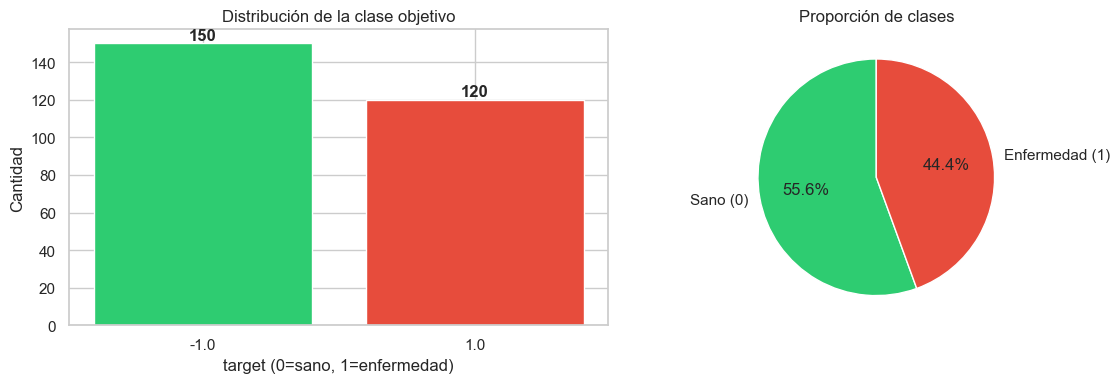

In [5]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['target'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('target (0=sano, 1=enfermedad)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['Sano (0)', 'Enfermedad (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

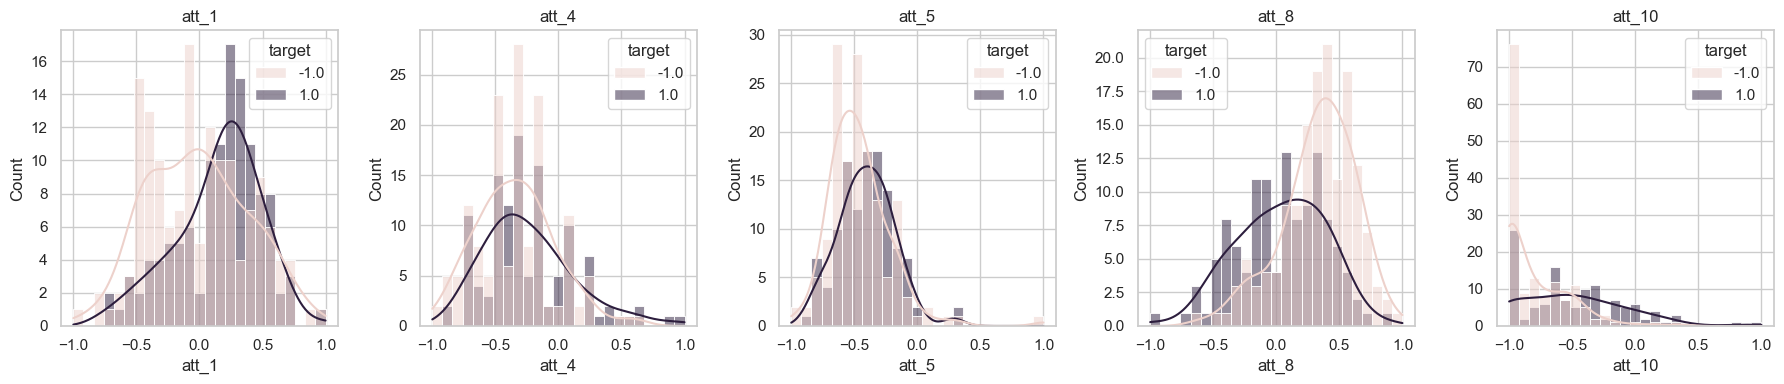

In [6]:
# 3.4  Distribución de variables numéricas clave
# Mapeo de nombres originales a nombres genéricos de OpenML
# 'age' -> 'att_1'
# 'trestbps' -> 'att_4'
# 'chol' -> 'att_5'
# 'thalach' -> 'att_8'
# 'oldpeak' -> 'att_10'
num_cols = ['att_1', 'att_4', 'att_5', 'att_8', 'att_10']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

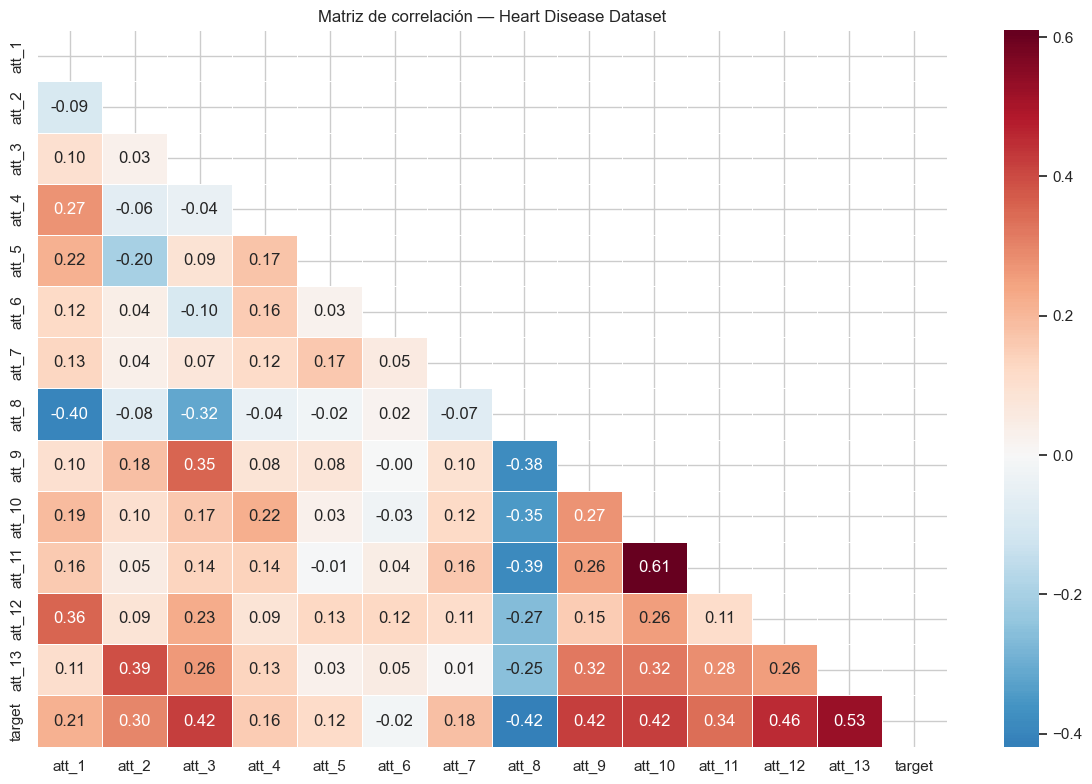

In [7]:
# 3.5  Matriz de correlación
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Heart Disease Dataset')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [8]:
# 4.1  Separación de features y target
X = df.drop(columns='target')
y = df['target']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (270, 13)
Target:   (270,)


In [9]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 216 muestras
Test:  54 muestras

Proporción target en train:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64

Proporción target en test:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [10]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.8288 ± 0.0682
DecisionTree               Accuracy CV: 0.7637 ± 0.0350
RandomForest               Accuracy CV: 0.8148 ± 0.0390


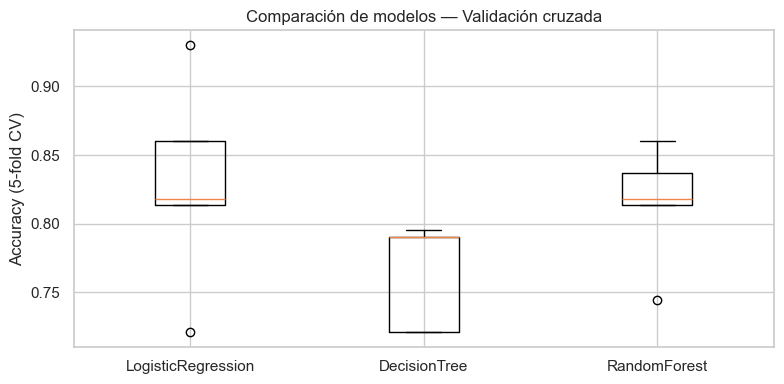

In [11]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [12]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Sano', 'Enfermedad']))

Mejor modelo: LogisticRegression
Accuracy en test: 0.8519

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Sano       0.92      0.80      0.86        30
  Enfermedad       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



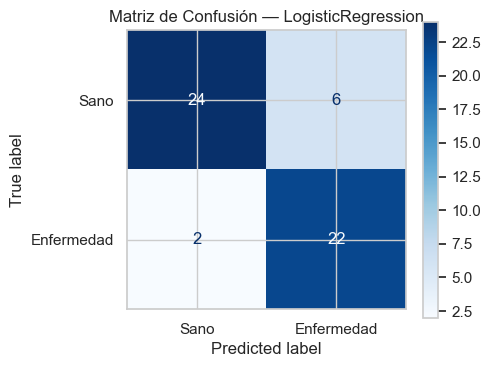

In [13]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Sano', 'Enfermedad'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

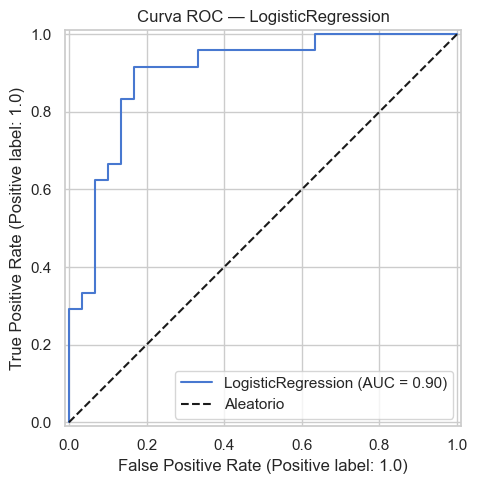

In [14]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [15]:
# 7.1  Guardar el modelo
MODEL_PATH = 'heart_disease_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: heart_disease_model.joblib


In [16]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [17]:
# 7.3  Función de inferencia (simula un endpoint de predicción)

def predict_heart_disease(patient_data: dict) -> dict:
    """
    Recibe un diccionario con los features del paciente
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)

    # Mapeo de nombres originales a nombres genéricos de OpenML
    feature_name_map = {
        'age': 'att_1',
        'sex': 'att_2',
        'cp': 'att_3',
        'trestbps': 'att_4',
        'chol': 'att_5',
        'fbs': 'att_6',
        'restecg': 'att_7',
        'thalach': 'att_8',
        'exang': 'att_9',
        'oldpeak': 'att_10',
        'slope': 'att_11',
        'ca': 'att_12',
        'thal': 'att_13'
    }

    # Renombrar las claves en patient_data y asegurar el orden correcto de las columnas
    # 'feature_names' es una variable global del kernel que contiene el orden correcto de las columnas
    # (e.g., ['att_1', 'att_2', ..., 'att_13'])
    try:
        renamed_patient_data_ordered = {feature_name_map[k]: patient_data[k] for k in feature_name_map.keys()}
        ordered_values = [renamed_patient_data_ordered[name] for name in feature_names]
        input_df = pd.DataFrame([ordered_values], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Missing or incorrect feature name in patient_data: {e}. Expected descriptive names from the mapping.")

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    # Ajustar etiquetas de predicción según las clases del modelo (-1.0 y 1.0)
    prediction_label = 'Enfermedad cardíaca' if pred == 1.0 else 'Sano'

    # Asumiendo que proba[0] es para la clase -1.0 (Sano) y proba[1] para 1.0 (Enfermedad)
    return {
        'prediccion': prediction_label,
        'probabilidad_enfermedad': round(float(proba[1]), 4),
        'probabilidad_sano': round(float(proba[0]), 4)
    }

# Ejemplo de uso con un paciente ficticio
paciente_ejemplo = {
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 140,
    'chol': 250, 'fbs': 0, 'restecg': 1, 'thalach': 150,
    'exang': 0, 'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
}

resultado = predict_heart_disease(paciente_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Enfermedad cardíaca
  probabilidad_enfermedad: 1.0
  probabilidad_sano: 0.0


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
## 10. Resolución — Ejercicio 1: Experimentación con hiperparámetros

Optimizamos los hiperparámetros del `RandomForestClassifier` con `GridSearchCV` y comparamos el accuracy del modelo **por defecto** (el mismo pipeline definido en la Etapa 4, Sección 5.1) contra el modelo **ajustado**.

> Nota: `GridSearchCV` prueba **todas** las combinaciones del `param_grid` de forma exhaustiva. Si el espacio de búsqueda es muy grande y el entrenamiento se vuelve lento, `RandomizedSearchCV` es una alternativa que muestrea un número fijo de combinaciones al azar (parámetro `n_iter`) — suele dar resultados casi tan buenos, mucho más rápido.

In [18]:
# 10.1  Accuracy del RandomForest "por defecto" (sin tuning) — línea base
rf_baseline = pipelines['RandomForest']
rf_baseline.fit(X_train, y_train)
baseline_acc = rf_baseline.score(X_test, y_test)

print(f'Accuracy RandomForest (por defecto): {baseline_acc:.4f}')

Accuracy RandomForest (por defecto): 0.8333


In [19]:
# 10.2  Definición del espacio de búsqueda y GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=pipelines['RandomForest'],
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'Mejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor accuracy en CV:    {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Mejores hiperparámetros: {'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}
Mejor accuracy en CV:    0.8473


In [20]:
# 10.3  Evaluación del modelo optimizado en el set de test
best_rf = grid_search.best_estimator_
tuned_acc = best_rf.score(X_test, y_test)

print(f'Accuracy RandomForest (por defecto): {baseline_acc:.4f}')
print(f'Accuracy RandomForest (optimizado):  {tuned_acc:.4f}')
print(f'Mejora: {(tuned_acc - baseline_acc) * 100:+.2f} puntos porcentuales')

y_pred_tuned = best_rf.predict(X_test)
print('\n' + '='*60)
print('CLASSIFICATION REPORT — RandomForest optimizado')
print('='*60)
print(classification_report(y_test, y_pred_tuned, target_names=['Sano', 'Enfermedad']))

Accuracy RandomForest (por defecto): 0.8333
Accuracy RandomForest (optimizado):  0.8519
Mejora: +1.85 puntos porcentuales

CLASSIFICATION REPORT — RandomForest optimizado
              precision    recall  f1-score   support

        Sano       0.87      0.87      0.87        30
  Enfermedad       0.83      0.83      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54



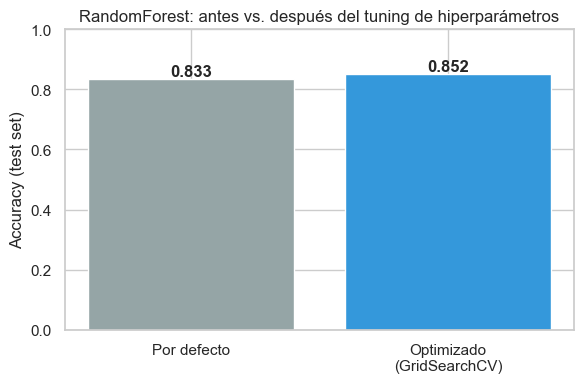

In [21]:
# 10.4  Comparación visual: accuracy antes vs. después del tuning
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Por defecto', 'Optimizado\n(GridSearchCV)'], [baseline_acc, tuned_acc],
       color=['#95a5a6', '#3498db'])
ax.set_ylabel('Accuracy (test set)')
ax.set_title('RandomForest: antes vs. después del tuning de hiperparámetros')
ax.set_ylim(0, 1)
for i, v in enumerate([baseline_acc, tuned_acc]):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Resolución — Ejercicio 2: Nuevo dataset, mismo pipeline

Replicamos el ciclo de vida completo (recolección → exploración → preparación → entrenamiento → evaluación → serialización) usando el dataset **Breast Cancer Wisconsin**, incluido directamente en Scikit-learn — no requiere descarga externa.

**El problema:** clasificar si un tumor de mama es **maligno (0)** o **benigno (1)** a partir de 30 mediciones numéricas obtenidas de imágenes digitalizadas (radio, textura, perímetro, área, suavidad, etc., cada una con su versión "mean", "error" y "worst").

**Diccionario de variables — Breast Cancer Wisconsin**

| Variable base | Descripción |
|---|---|
| **radius** (radio) | Distancia promedio desde el centro a los puntos del perímetro del núcleo celular |
| **texture** (textura) | Desviación estándar de los valores en escala de grises de la imagen |
| **perimeter** (perímetro) | Perímetro del núcleo celular |
| **area** (área) | Área del núcleo celular |
| **smoothness** (suavidad) | Variación local en las longitudes del radio |
| **compactness** (compacidad) | perímetro² / área − 1.0 |
| **concavity** (concavidad) | Severidad de las porciones cóncavas del contorno |
| **concave points** (puntos cóncavos) | Número de porciones cóncavas del contorno |
| **symmetry** (simetría) | Simetría del núcleo celular |
| **fractal dimension** (dimensión fractal) | Aproximación de la "línea de costa" del contorno, menos 1 |
| **target** | Diagnóstico (**0 = Maligno**, **1 = Benigno**) |

> Cada una de estas 10 características se calculó de **3 formas distintas** por imagen: **mean** (promedio), **error** (error estándar) y **worst** (promedio de los 3 valores más grandes/peores). Por eso el dataset tiene **30 columnas numéricas** en total (10 × 3) + `target`. Por ejemplo, para "radius" existen `mean radius`, `radius error` y `worst radius`.

In [22]:
# 11.1  Recolección de datos — Breast Cancer Wisconsin (incluido en sklearn)
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df2 = pd.DataFrame(data=data.data, columns=data.feature_names)
df2['target'] = data.target

print(f'Dataset cargado — {df2.shape[0]} registros, {df2.shape[1]} columnas')
print(f'Clases: {dict(zip(data.target_names, range(len(data.target_names))))}')
df2.head()

Dataset cargado — 569 registros, 31 columnas
Clases: {'malignant': 0, 'benign': 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 11.2  Exploración y preparación de datos

In [23]:
# 11.2.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df2.info()
print('\n')
df2.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  sm

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


In [24]:
# 11.2.2  Verificación de valores nulos y duplicados
print(f'Total de valores nulos: {df2.isnull().sum().sum()}')
print(f'Registros duplicados: {df2.duplicated().sum()}')

df2 = df2.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df2.shape[0]}')

Total de valores nulos: 0
Registros duplicados: 0
Registros después de limpieza: 569


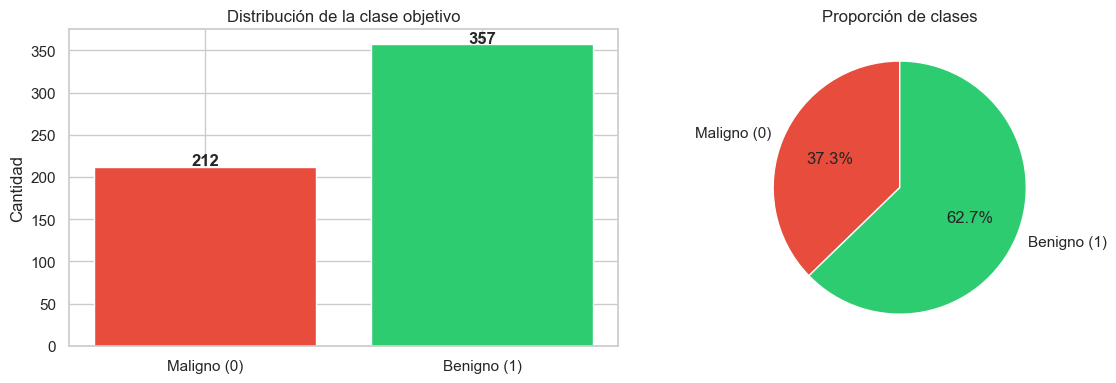

In [25]:
# 11.2.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels_map = {0: 'Maligno (0)', 1: 'Benigno (1)'}
target_counts2 = df2['target'].value_counts().sort_index()

axes[0].bar([labels_map[i] for i in target_counts2.index], target_counts2.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts2.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts2.values, labels=[labels_map[i] for i in target_counts2.index],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

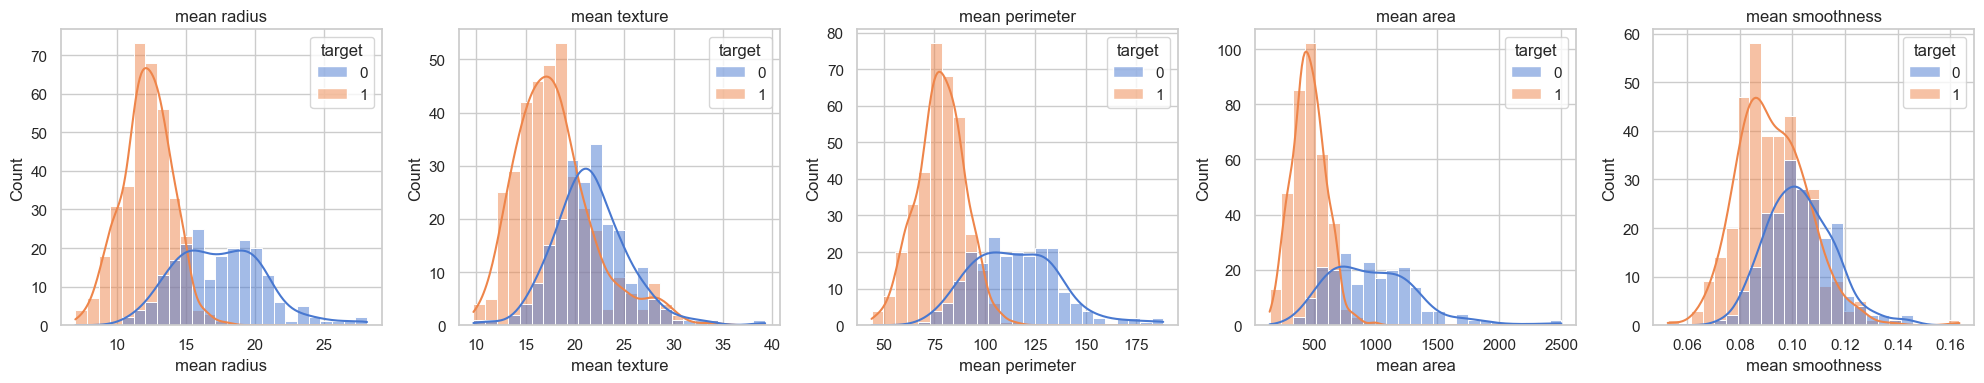

In [26]:
# 11.2.4  Distribución de variables numéricas clave
num_cols2 = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

fig, axes = plt.subplots(1, len(num_cols2), figsize=(20, 4))
for ax, col in zip(axes, num_cols2):
    sns.histplot(data=df2, x=col, hue='target', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

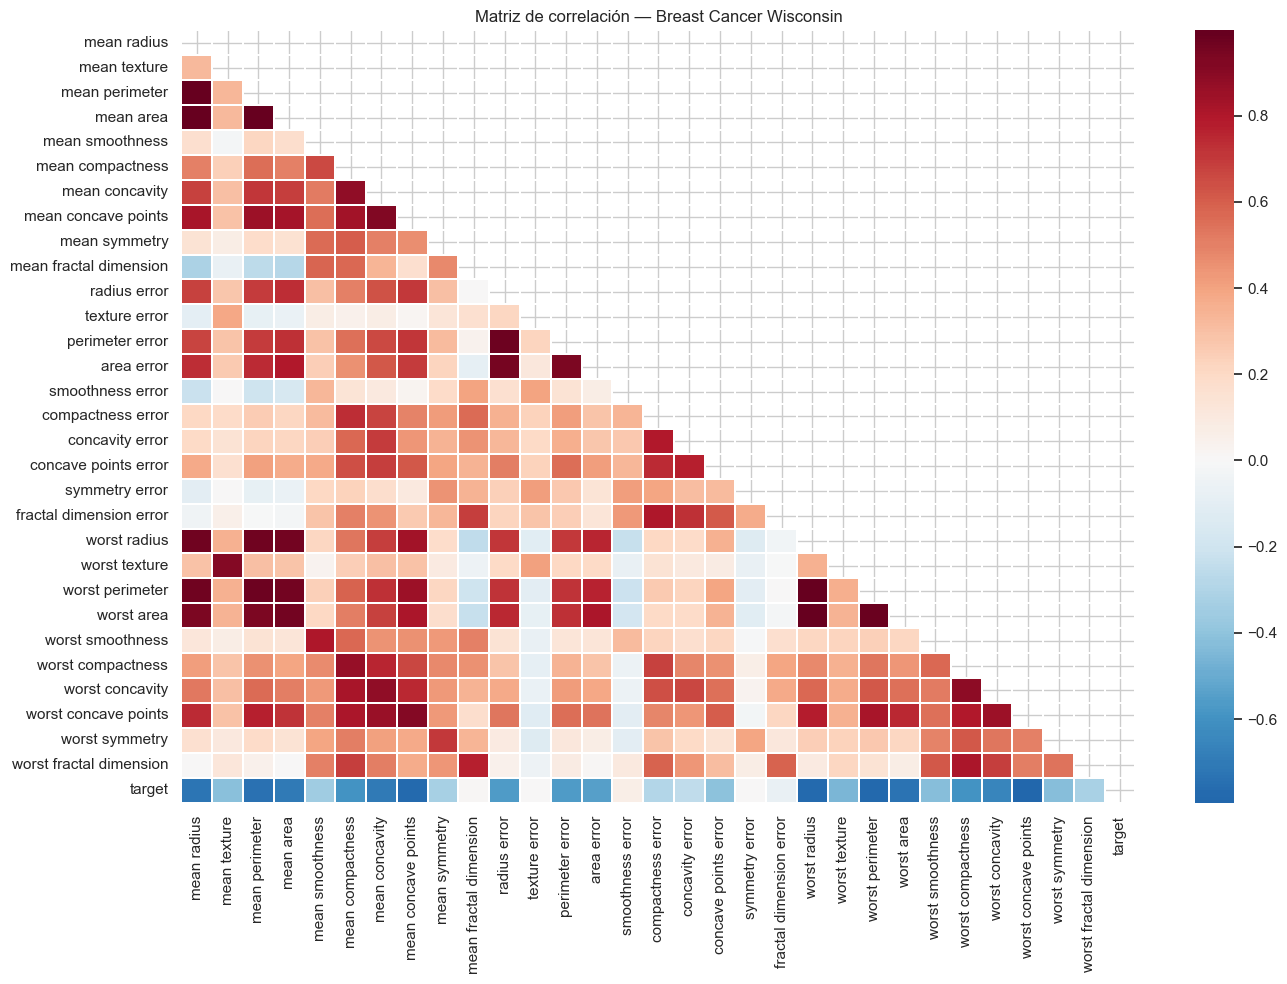

In [27]:
# 11.2.5  Matriz de correlación (30 variables → sin anotaciones para mantenerla legible)
plt.figure(figsize=(14, 10))
corr2 = df2.corr(numeric_only=True)
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask2, cmap='RdBu_r', center=0, linewidths=0.3)
plt.title('Matriz de correlación — Breast Cancer Wisconsin')
plt.tight_layout()
plt.show()

### 11.3  Preparación de datos para el modelado

In [28]:
# 11.3.1  Separación de features y target
X2 = df2.drop(columns='target')
y2 = df2['target']

print(f'Features: {X2.shape}')
print(f'Target:   {y2.shape}')

Features: (569, 30)
Target:   (569,)


In [29]:
# 11.3.2  División train / test (80-20, estratificado)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)

print(f'Train: {X2_train.shape[0]} muestras')
print(f'Test:  {X2_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y2_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y2_test.value_counts(normalize=True).round(3)}')

Train: 455 muestras
Test:  114 muestras

Proporción target en train:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Proporción target en test:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


### 11.4  Entrenamiento de modelos

In [30]:
# 11.4.1  Definición de pipelines y validación cruzada (5-fold)
pipelines2 = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

results2 = {}
for name, pipe in pipelines2.items():
    scores = cross_val_score(pipe, X2_train, y2_train, cv=5, scoring='accuracy')
    results2[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.9802 ± 0.0128
DecisionTree               Accuracy CV: 0.9319 ± 0.0213
RandomForest               Accuracy CV: 0.9582 ± 0.0213


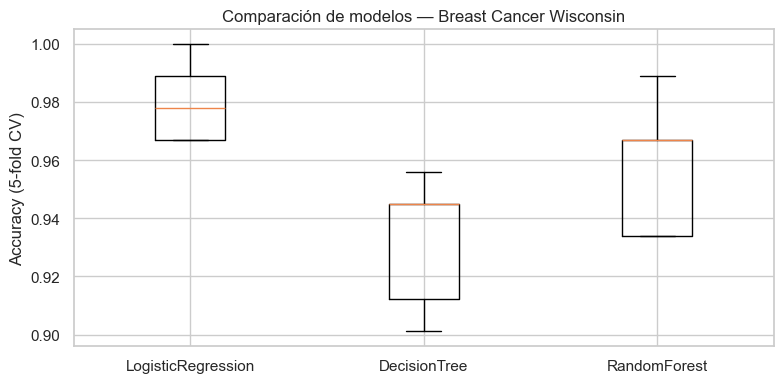

In [31]:
# 11.4.2  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results2.values(), tick_labels=results2.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Breast Cancer Wisconsin')
plt.tight_layout()
plt.show()

### 11.5  Evaluación del mejor modelo

In [32]:
# 11.5.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name2 = max(results2, key=lambda k: results2[k].mean())
best_pipeline2 = pipelines2[best_name2]
best_pipeline2.fit(X2_train, y2_train)

y2_pred = best_pipeline2.predict(X2_test)

print(f'Mejor modelo: {best_name2}')
print(f'Accuracy en test: {best_pipeline2.score(X2_test, y2_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y2_test, y2_pred, target_names=['Maligno', 'Benigno']))

Mejor modelo: LogisticRegression
Accuracy en test: 0.9825

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



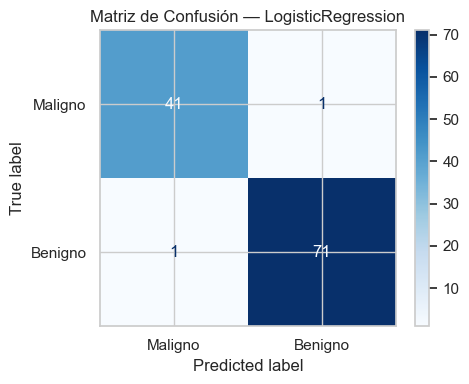

In [33]:
# 11.5.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y2_test, y2_pred,
    display_labels=['Maligno', 'Benigno'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name2}')
plt.tight_layout()
plt.show()

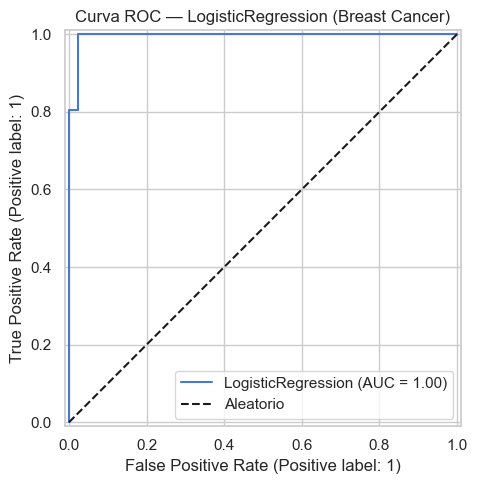

In [34]:
# 11.5.3  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline2, X2_test, y2_test, ax=ax, name=best_name2)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name2} (Breast Cancer)')
ax.legend()
plt.tight_layout()
plt.show()

### 11.6  Serialización y despliegue conceptual

In [35]:
# 11.6.1  Guardar el modelo
MODEL_PATH_2 = 'breast_cancer_model.joblib'
joblib.dump(best_pipeline2, MODEL_PATH_2)
print(f'Modelo guardado en: {MODEL_PATH_2}')

Modelo guardado en: breast_cancer_model.joblib


In [36]:
# 11.6.2  Cargar y verificar el modelo serializado
loaded_model2 = joblib.load(MODEL_PATH_2)

assert np.array_equal(loaded_model2.predict(X2_test), y2_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [37]:
# 11.6.3  Función de inferencia (simula un endpoint de predicción)

def predict_breast_cancer(patient_data: dict) -> dict:
    """
    Recibe un diccionario con las 30 mediciones del tumor
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH_2)

    ordered_values = [patient_data[name] for name in data.feature_names]
    input_df = pd.DataFrame([ordered_values], columns=data.feature_names)

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    prediction_label = 'Benigno' if pred == 1 else 'Maligno'

    return {
        'prediccion': prediction_label,
        'probabilidad_maligno': round(float(proba[0]), 4),
        'probabilidad_benigno': round(float(proba[1]), 4)
    }

# Ejemplo de uso con un caso real del set de test
caso_ejemplo = X2_test.iloc[0].to_dict()
resultado2 = predict_breast_cancer(caso_ejemplo)

print('\n--- Resultado de inferencia ---')
for k, v in resultado2.items():
    print(f'  {k}: {v}')
etiqueta_real = 'Benigno' if y2_test.iloc[0] == 1 else 'Maligno'
print(f'\n(Etiqueta real: {etiqueta_real})')


--- Resultado de inferencia ---
  prediccion: Maligno
  probabilidad_maligno: 1.0
  probabilidad_benigno: 0.0

(Etiqueta real: Maligno)


---
### Resumen — Ejercicio 2

| Etapa | Heart Disease (original) | Breast Cancer (Ejercicio 2) |
|---|---|---|
| **Recolección** | Descarga por URL con fallback a OpenML | `load_breast_cancer()` directo de sklearn |
| **Tamaño** | 303 registros, 14 columnas | 569 registros, 31 columnas |
| **Balance de clases** | ~54% / 46% | ~63% / 37% |
| **Modelos y evaluación** | Idéntico: 3 pipelines, CV 5-fold, accuracy/ROC/matriz de confusión | Idéntico |
| **Despliegue** | joblib + función de inferencia | joblib + función de inferencia |

El pipeline completo es **reutilizable tal cual** cuando el nuevo dataset ya viene limpio y numérico — la única adaptación real fue la carga de datos y los nombres de columnas/etiquetas.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*